In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [26]:
data = pd.read_csv("/Mall_Customers.csv")

In [27]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
kmeans = KMeans(n_clusters=5, random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)


In [30]:
print(data.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


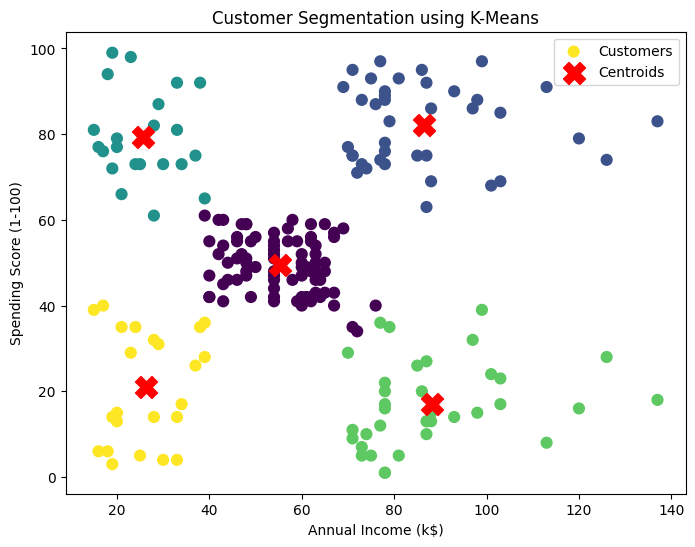

In [31]:
plt.figure(figsize=(8,6))

# Customers
plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster'],
    cmap='viridis',
    s=60,
    label='Customers'
)

# Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()